In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path

from nbqol import path_to_git_root
ROOT = Path(path_to_git_root()) # automatically makes path to repo directory (wherever you cloned it)

print("Repository directory: ", ROOT)

Repository directory:  /Users/timothy/Documents/EV-Resistance-analysis


In [2]:
QPCR = ROOT / "qPCR-validation" / "qpcr_data"
RNASEQ = ROOT / "qPCR-validation" / "bulkRNAseq_data"
OUTPUT = ROOT / "qPCR-validation" / "outs"

#UMUC1 + HT8
umuc1_ht8_qpcr_df = pd.read_csv(QPCR / "QPCR_6-12_UMUC1-HT8.csv")
umuc1_ht8_rnaseq_df = pd.read_csv(RNASEQ / "bulkRNA_UMUC1_parental_vs_resistant.csv")

#RT112 + 2F2
rt112_2f2_qpcr_df = pd.read_csv(QPCR / "QPCR_6-15_RT112-2F2E-2F2L.csv")
rt112_2f2_rnaseq_df = pd.read_csv(RNASEQ / "bulkRNA_RT112_parental_vs_resistant.csv")

#647V + 1C2
v647_qpcr_df = pd.read_csv(QPCR / "QPCR_6-16_647V-1C2.csv")
v647_rnaseq_df = pd.read_csv(RNASEQ / "bulkRNA_647V_parental_vs_resistant.csv")

crispr_df_umuc1_ht8_647v_1c2 = pd.read_csv(QPCR / "QPCR_umuc1_ht8_647v_1c2_crispr.csv")

umuc1_ht8_crispr_df = crispr_df_umuc1_ht8_647v_1c2[
        crispr_df_umuc1_ht8_647v_1c2["Sample Name"].isin(["UMUC1", "HT8"])
].copy()

v647_1c2_crispr_df = crispr_df_umuc1_ht8_647v_1c2[
        crispr_df_umuc1_ht8_647v_1c2["Sample Name"].isin(["647V", "1C2"])
].copy()

rt112_2f2_crispr_df = pd.read_csv(QPCR / "QPCR_rt112_2f2_crispr.csv")


In [3]:
# ===========
# Gene sets
# ===========

tim_upregulated = [
    "AGAP2",
    "DNM3",
    "ADAM12",
    "ABCB1",
    "IL6",
    "FZD8",
    "TUBA4A",
    "F2R",
    "CTSE",
    "CTSF",
    "RET"
]

tim_downregulated = [
    "FAP",
    "EHD3",
    "GJA1",
    "PSAPL1",
    "PDZK1",
    "ABCG1",
    "BBC3",
    "CHMP4B",
    "CAV1",
    "PPT2",
    "NEDD4L",
]

will_upregulated = [
    "ZNF611",
    "MELTF",
    "IL32",
    "UST",
    "TMCC2",
    "PLOD2",
    "SAT1", 
    "PSCK9", "PRSS1", "PRSS2", "ABCB1"
]


will_downregulated = [
    "GJB1", "KRT81","DAPK1",
    "ZBED2","ACAT2","WNT10A",
    "UPK1B","IGFBP3","S100A14",
    "SLC7A5","EMP1","BCAT1",
    "TPX2","CLIC4","SH2D4A", "CAM2KN1", "SH2D4A", "C1QTNF6", "SLC7A5"
]

crispr_upregulated = [
    "ABCB9",
    "LTC4S",
    "TTBK1",
    "PEX11G",
    "HEATR3",
    "SLC24A1",
    "SLITRK6"]

crispr_downregulated = [
    "CDC20",
    "PLD2",
    "MARCH3",
    "SH3KBP1",
    "HMGB3",
    "FGFR3",
    "TP53I11",
    "SLC9A4",
    "RRAGC",
    "TRIM47",
    "SLC16A7",
    "ALDOA",
]

In [4]:
def calculate_ddct(df, goi, hkg, reference_sample, test_sample):
    """
    Calculate 2^-ΔΔCt for qPCR data.

    Parameters:
        df               : DataFrame with columns [Sample Name, Target Name, CT]
        goi              : Gene of interest, string, case-insensitive
        hkg              : Housekeeping gene string OR list of housekeeping genes
        reference_sample : Reference/control sample name
        test_sample      : Test sample name

    Returns:
        final 2^-ΔΔCt
    """

    df = df.copy()

    # Normalize columns
    df['Target Name'] = df['Target Name'].astype(str).str.lower().str.strip()
    df['Sample Name'] = df['Sample Name'].astype(str).str.strip()

    goi = goi.lower().strip()
    reference_sample = reference_sample.strip()
    test_sample = test_sample.strip()

    # Allow hkg to be a string or a list
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    # Replace 'Undetermined' or bad CT values with NaN
    df['CT'] = pd.to_numeric(df['CT'], errors='coerce')

    def mean_ct(sample, target):
        vals = df[
            (df['Sample Name'] == sample) &
            (df['Target Name'] == target)
        ]['CT']

        if vals.empty:
            raise ValueError(f"No CT values found for {sample} / {target}")

        if vals.isna().all():
            raise ValueError(f"All CT values are Undetermined for {sample} / {target}")

        return vals.mean()

    def mean_hkg_ct(sample):
        """
        Average the mean CT of each housekeeping gene.
        This prevents a housekeeping gene with more replicates from being weighted more heavily.
        """
        hkg_means = [mean_ct(sample, gene) for gene in hkg_list]
        return np.mean(hkg_means)

    # Average CT values
    ct_goi_ref = mean_ct(reference_sample, goi)
    ct_goi_test = mean_ct(test_sample, goi)

    ct_hkg_ref = mean_hkg_ct(reference_sample)
    ct_hkg_test = mean_hkg_ct(test_sample)

    # ΔCt = CT(GOI) - CT(HKG average)
    dct_reference = ct_goi_ref - ct_hkg_ref
    dct_test = ct_goi_test - ct_hkg_test

    # ΔΔCt = ΔCt(test) - ΔCt(reference)
    ddct = dct_test - dct_reference

    # 2^-ΔΔCt
    expression = 2 ** (-ddct)

    return expression

In [5]:
# results = calculate_ddct(
#     df=qpcr_df,
#     goi="CLIC4",
#     hkg=["hprt", "gapdh"],
#     reference_sample="1C2",
#     test_sample="647V"
# )
# print(results)

# for target in pd.unique(qpcr_df['Target Name']):
#     print(target)

In [7]:
def plot_qpcr_vs_rnaseq(
    qpcr_df,
    rnaseq_df,
    hkg,
    reference_sample,
    test_sample,
    ncols=6,
    color1='darkturquoise',
    color2='mediumvioletred',
    genes_to_include=None
):
    """
    Plots multi-row grouped bar chart comparing qPCR log2FC vs RNAseq log2FC.
    All rows share the same y-axis scale.

    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        rnaseq_df        : DESeq2-style DataFrame with columns [log2FoldChange, GeneSymbol, ...]
        hkg              : Housekeeping gene name OR list of housekeeping gene names
        reference_sample : Reference sample name
        test_sample      : Test sample name
        ncols            : Number of genes per row
        genes_to_include : Optional list of genes to plot, in the given order
    """

    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue

            y = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va=va,
                fontsize=7,
                fontweight='bold'
            )

    # --- qPCR: clean input ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].astype(str).str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].astype(str).str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    # Allow hkg to be a string or a list
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    if len(hkg_list) == 0:
        raise ValueError("At least one housekeeping gene must be provided.")

    hkg_set = set(hkg_list)
    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [
            t for t in qpcr_df['Target Name'].unique()
            if t not in hkg_set
        ]
    else:
        # Normalize requested genes, remove duplicates, and preserve input order
        seen = set()
        requested_genes = []

        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower not in seen:
                requested_genes.append(g_lower)
                seen.add(g_lower)

        goi_list = []

        for g in requested_genes:
            if g in hkg_set:
                print(f"Skipping '{g.upper()}': this is one of the housekeeping genes.")
            elif g not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g)

    # --- Calculate qPCR log2FC ---
    qpcr_log2fc = {}

    for goi in goi_list:
        try:
            res = calculate_ddct(
                qpcr_df,
                goi,
                hkg_list,
                reference_sample,
                test_sample
            )

            qpcr_log2fc[goi] = np.log2(res)

        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]

    if len(genes) == 0:
        raise ValueError("No genes available to plot after filtering.")

    # --- RNAseq: extract log2FC from DESeq2 results table ---
    rnaseq_df = rnaseq_df.copy()
    rnaseq_df['GeneSymbol'] = rnaseq_df['GeneSymbol'].astype(str).str.lower().str.strip()

    rnaseq_lookup = pd.to_numeric(
        rnaseq_df.set_index('GeneSymbol')['log2FoldChange'],
        errors='coerce'
    )

    qpcr_vals = [qpcr_log2fc[g] for g in genes]
    rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

    for g, rv in zip(genes, rnaseq_vals):
        if np.isnan(rv):
            print(f"Warning: '{g.upper()}' not found in RNAseq data — bar will be absent.")

    # --- Plot as multi-row grouped bar chart ---
    width = 0.35
    nrows = math.ceil(len(genes) / ncols)

    fig, axes = plt.subplots(
        nrows,
        1,
        figsize=(ncols * 1.4, nrows * 4),
        sharey=True
    )

    if nrows == 1:
        axes = [axes]

    for row in range(nrows):
        ax = axes[row]

        row_genes = genes[row * ncols:(row + 1) * ncols]
        row_qpcr = qpcr_vals[row * ncols:(row + 1) * ncols]
        row_rnaseq = rnaseq_vals[row * ncols:(row + 1) * ncols]

        x = np.arange(len(row_genes))

        bars1 = ax.bar(
            x - width / 2,
            row_qpcr,
            width,
            color=color1,
            edgecolor='black',
            linewidth=0.8
        )

        bars2 = ax.bar(
            x + width / 2,
            row_rnaseq,
            width,
            color=color2,
            edgecolor='black',
            linewidth=0.8
        )

        _label_bars(ax, bars1)
        _label_bars(ax, bars2)

        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([g.upper() for g in row_genes], rotation=45, ha='right')
        ax.set_ylabel('log$_2$FC', fontsize=10)

    axes[0].legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color=color1, ec='black'),
            plt.Rectangle((0, 0), 1, 1, color=color2, ec='black')
        ],
        labels=['qPCR', 'Bulk RNAseq'],
        fontsize=10
    )

    hkg_label = ", ".join([gene.upper() for gene in hkg_list])

    fig.suptitle(
        f'{test_sample} vs {reference_sample} normalized to {hkg_label}',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()

    fname = f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved as {fname}")

In [ ]:
endocytosis_confirmed = [
    "AGAP2", "DNM3", "RET", "F2R", "MELTF"
]

EMT_confirmed = [
    "ADAM12", "FZD8", "PLOD2"
]

immune_modulation_confirmed = [
    "IL6", "ZBED2"
]

apoptosis_confirmed = [
    "SAT1", "UPK1B"
]

uncategorized_confirmed = [
    "ZNF611", "UST", "TMCC2"
]

In [6]:
plot_qpcr_vs_rnaseq(
    qpcr_df=rt112_2f2_crispr_df,
    rnaseq_df=rt112_2f2_rnaseq_df,
    hkg=["actin", "gapdh", "hprt"],
    test_sample=["2F2-EARLY","2F2-LATE"],
    reference_sample="RT112",
    genes_to_include=crispr_downregulated,
    color1='teal', color2='mediumpurple'
)

AttributeError: 'list' object has no attribute 'strip'

In [ ]:
def plot_qpcr_only(
    qpcr_df,
    hkg,
    reference_sample,
    test_sample,
    ncols=6,
    color='darkturquoise',
    genes_to_include=None
):
    """
    Plots multi-row bar chart of qPCR log2FC values.
    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        hkg              : Housekeeping gene name OR list of housekeeping gene names
        reference_sample : Reference sample name
        test_sample      : Test sample name
        ncols            : Number of genes per row
        color            : Bar color
        genes_to_include : Optional list of genes to plot, in the given order
    """
    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue
            y  = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va=va,
                fontsize=7,
                fontweight='bold'
            )

    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].astype(str).str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].astype(str).str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    if len(hkg_list) == 0:
        raise ValueError("At least one housekeeping gene must be provided.")

    hkg_set     = set(hkg_list)
    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # Select GOIs
    if genes_to_include is None:
        goi_list = [t for t in qpcr_df['Target Name'].unique() if t not in hkg_set]
    else:
        seen, goi_list = set(), []
        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower in seen:
                continue
            seen.add(g_lower)
            if g_lower in hkg_set:
                print(f"Skipping '{g.upper()}': housekeeping gene.")
            elif g_lower not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g_lower)

    # Calculate log2FC
    qpcr_log2fc = {}
    for goi in goi_list:
        try:
            fc = calculate_ddct(qpcr_df, goi, hkg_list, reference_sample, test_sample)
            qpcr_log2fc[goi] = np.log2(fc)
        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]
    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    qpcr_vals = [qpcr_log2fc[g] for g in genes]

    # Plot
    nrows = math.ceil(len(genes) / ncols)
    fig, axes = plt.subplots(nrows, 1, figsize=(ncols * 1.4, nrows * 4), sharey=True)
    if nrows == 1:
        axes = [axes]

    for row in range(nrows):
        ax         = axes[row]
        row_genes  = genes[row * ncols:(row + 1) * ncols]
        row_vals   = qpcr_vals[row * ncols:(row + 1) * ncols]
        x          = np.arange(len(row_genes))

        bars = ax.bar(x, row_vals, color=color, edgecolor='black', linewidth=0.8)
        _label_bars(ax, bars)

        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([g.upper() for g in row_genes], rotation=45, ha='right')
        ax.set_ylabel('log$_2$FC', fontsize=10)

    hkg_label = ", ".join(g.upper() for g in hkg_list)
    fig.suptitle(
        f'{test_sample} vs {reference_sample} normalized to {hkg_label}',
        fontsize=12,
        fontweight='bold'
    )
    plt.tight_layout()

    fname = f'qpcr_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved as {fname}")

In [11]:
def individual_plot_qpcr_vs_rnaseq(
    qpcr_df,
    rnaseq_dfs,
    comparisons,
    hkg=["actin", "gapdh", "hprt"],
    color1="navy",
    color2="goldenrod",
    genes_to_include=None,
    output_folder="."
):
    """
    Plots one figure per gene, each showing paired qPCR vs RNAseq log2FC bars
    for each (test, reference) comparison. All plots share the same y-axis scale.

    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        rnaseq_dfs       : List of DESeq2-style DataFrames, one per comparison
        comparisons      : List of (test_sample, reference_sample) tuples
        hkg              : Housekeeping gene name or list of housekeeping gene names
        color1           : Bar color for qPCR
        color2           : Bar color for RNAseq
        genes_to_include : Optional list of genes to plot, in given order
        output_folder    : Folder in which plot files will be saved
    """

    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue

            y = h + (0.05 if h >= 0 else -0.05)
            va = "bottom" if h >= 0 else "top"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{h:.2f}",
                ha="center",
                va=va,
                fontsize=7,
                fontweight="bold"
            )

    # Create the output folder if it does not already exist
    output_folder = Path(output_folder).expanduser()
    output_folder.mkdir(parents=True, exist_ok=True)

    # --- Validate inputs ---
    if len(rnaseq_dfs) != len(comparisons):
        raise ValueError("rnaseq_dfs and comparisons must have the same length.")

    # --- Clean qPCR ---
    qpcr_df = qpcr_df.copy()
    qpcr_df["Target Name"] = (
        qpcr_df["Target Name"].astype(str).str.lower().str.strip()
    )
    qpcr_df["Sample Name"] = qpcr_df["Sample Name"].astype(str).str.strip()
    qpcr_df["CT"] = pd.to_numeric(qpcr_df["CT"], errors="coerce")

    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [g.lower().strip() for g in hkg]

    if not hkg_list:
        raise ValueError("At least one housekeeping gene must be provided.")

    hkg_set = set(hkg_list)
    qpcr_targets = set(qpcr_df["Target Name"].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [
            target
            for target in qpcr_df["Target Name"].unique()
            if target not in hkg_set
        ]
    else:
        seen = set()
        goi_list = []

        for gene in genes_to_include:
            gene_lower = gene.lower().strip()

            if gene_lower in seen:
                continue

            seen.add(gene_lower)

            if gene_lower in hkg_set:
                print(f"Skipping '{gene.upper()}': housekeeping gene.")
            elif gene_lower not in qpcr_targets:
                print(
                    f"Warning: '{gene.upper()}' not found in qPCR data, skipped."
                )
            else:
                goi_list.append(gene_lower)

    # --- Clean RNAseq DataFrames ---
    rnaseq_lookups = []

    for df in rnaseq_dfs:
        df = df.copy()
        df["GeneSymbol"] = (
            df["GeneSymbol"].astype(str).str.lower().str.strip()
        )

        lookup = pd.to_numeric(
            df.set_index("GeneSymbol")["log2FoldChange"],
            errors="coerce"
        )
        rnaseq_lookups.append(lookup)

    # --- Compute qPCR log2FC per gene per comparison ---
    gene_data = {}

    for goi in goi_list:
        qpcr_vals = []
        rnaseq_vals = []
        valid = False

        for (
            test_sample,
            reference_sample
        ), rnaseq_lookup in zip(comparisons, rnaseq_lookups):
            try:
                res = calculate_ddct(
                    qpcr_df,
                    goi,
                    hkg_list,
                    reference_sample,
                    test_sample
                )
                qv = np.log2(res)
                valid = True
            except ValueError as exc:
                print(
                    f"Skipping {goi.upper()} in "
                    f"{test_sample} vs {reference_sample}: {exc}"
                )
                qv = np.nan

            rv = rnaseq_lookup.get(goi, np.nan)

            if np.isnan(rv):
                print(
                    f"Warning: '{goi.upper()}' not found in RNAseq for "
                    f"{test_sample} vs {reference_sample}, bar will be absent."
                )

            qpcr_vals.append(qv)
            rnaseq_vals.append(rv)

        if valid:
            gene_data[goi] = (qpcr_vals, rnaseq_vals)

    genes = [gene for gene in goi_list if gene in gene_data]

    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    # --- Compute shared y-axis limits ---
    all_vals = []

    for goi in genes:
        qpcr_vals, rnaseq_vals = gene_data[goi]
        all_vals.extend(
            value
            for value in qpcr_vals + rnaseq_vals
            if not np.isnan(value)
        )

    y_min = min(all_vals)
    y_max = max(all_vals)
    y_range = y_max - y_min
    y_pad = y_range * 0.15 if y_range > 0 else 0.5
    y_lim = (y_min - y_pad, y_max + y_pad)

    # --- Plot ---
    n_comparisons = len(comparisons)
    width = 0.35
    x = np.arange(n_comparisons)
    x_labels = [f"{test}\nvs {reference}" for test, reference in comparisons]
    hkg_label = ", ".join(gene.upper() for gene in hkg_list)

    for goi in genes:
        qpcr_vals, rnaseq_vals = gene_data[goi]

        fig, ax = plt.subplots(
            figsize=(max(n_comparisons * 1.5, 5), 4)
        )

        bars1 = ax.bar(
            x - width / 2,
            qpcr_vals,
            width,
            color=color1,
            edgecolor="black",
            linewidth=0.8
        )
        bars2 = ax.bar(
            x + width / 2,
            rnaseq_vals,
            width,
            color=color2,
            edgecolor="black",
            linewidth=0.8
        )

        _label_bars(ax, bars1)
        _label_bars(ax, bars2)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_ylabel("log$_2$FC", fontsize=10)
        ax.set_ylim(y_lim)
        ax.set_title(
            f"{goi.upper()} — normalized to {hkg_label}",
            fontsize=11,
            fontweight="bold"
        )
        ax.legend(
            handles=[
                plt.Rectangle(
                    (0, 0), 1, 1, color=color1, ec="black"
                ),
                plt.Rectangle(
                    (0, 0), 1, 1, color=color2, ec="black"
                )
            ],
            labels=["qPCR", "Bulk RNAseq"],
            fontsize=10
        )

        plt.tight_layout()

        output_path = output_folder / f"qpcr_vs_rnaseq_{goi.upper()}.png"
        fig.savefig(output_path, dpi=350, bbox_inches="tight")

        plt.show()
        plt.close(fig)

        print(f"Saved as {output_path}")

In [13]:
v647_1c2_crispr_df

,Sample Name,Target Name,CT,Ct Mean,Ct SD,HIGHSD,NOAMP,EXPFAIL,MTP
8,647V,ACTINH,18.11,18.113,0.005,N,N,N,Y
9,647V,ACTINH,18.116,18.113,0.005,N,N,N,Y
10,647V,RRAGC,29.799,29.890,0.128,N,N,N,Y
11,647V,RRAGC,29.98,29.890,0.128,N,N,N,Y
12,1C2,ACTIN,17.984,17.967,0.024,N,N,N,Y
...,...,...,...,...,...,...,...,...,...
159,1C2,ABCB1,28.366,28.444,0.112,N,N,N,N
164,647V,TP53I11,31.994,31.921,0.103,N,N,N,N
165,647V,TP53I11,31.848,31.921,0.103,N,N,N,Y
166,1C2,TP53I11,31.678,31.533,0.205,N,N,N,Y


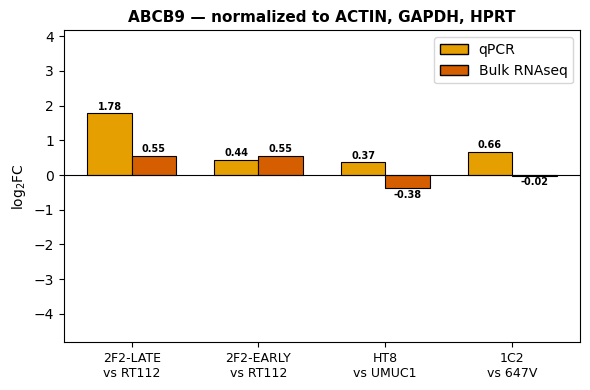

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_ABCB9.png


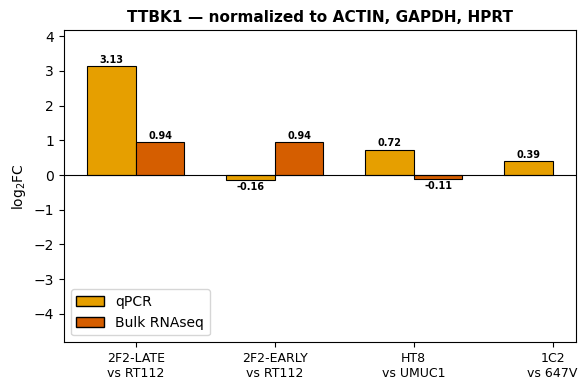

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_TTBK1.png


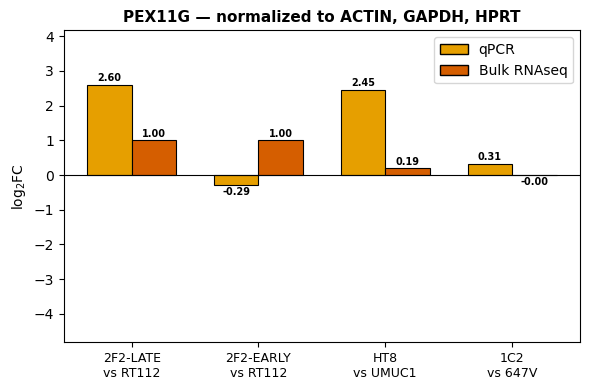

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_PEX11G.png


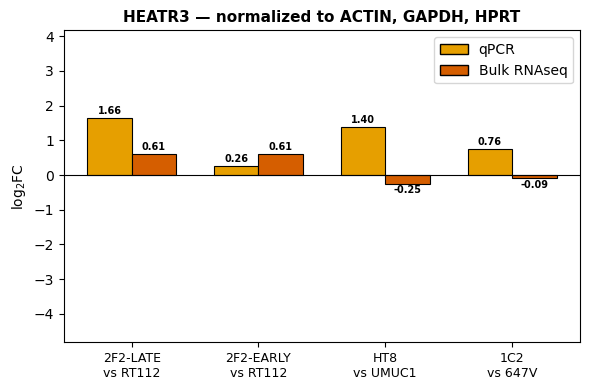

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_HEATR3.png


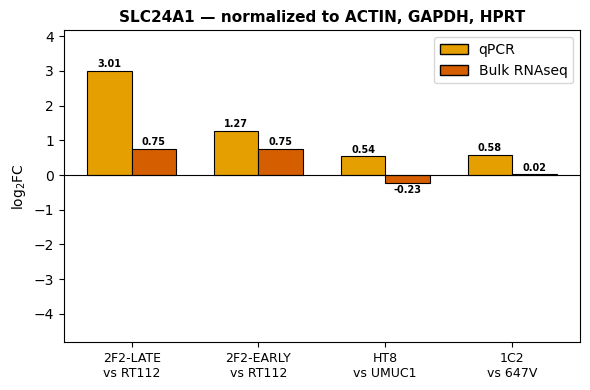

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_SLC24A1.png


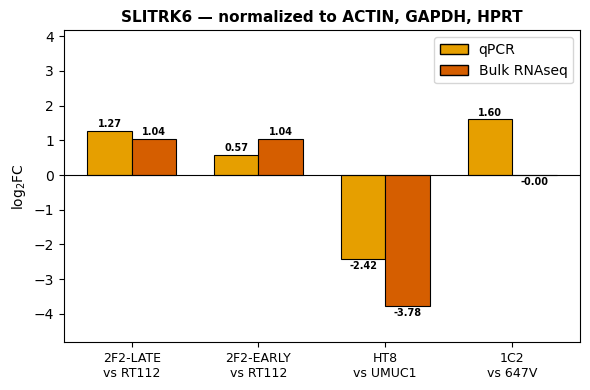

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/crispr_upregulated/qpcr_vs_rnaseq_SLITRK6.png


In [ ]:
# CRISPR Genes



individual_plot_qpcr_vs_rnaseq(
    qpcr_df=pd.concat([umuc1_ht8_crispr_df, rt112_2f2_crispr_df, v647_1c2_crispr_df]),
    rnaseq_dfs=[
    rt112_2f2_rnaseq_df,               # 2F2 vs RT112 
    rt112_2f2_rnaseq_df,
    umuc1_ht8_rnaseq_df,            # HT8 vs UMUC1
    v647_rnaseq_df                  # 1C2 vs 647V
],
    comparisons=[
        ("2F2-LATE", "RT112"),
        ("2F2-EARLY", "RT112"),
        ("HT8", "UMUC1"),
        ("1C2", "647V")
    ],
    hkg=["actin", "gapdh", "hprt"],
    color1='#E69F00',
    color2='#D55E00',
    genes_to_include=crispr_upregulated,
    output_folder=OUTPUT / "crispr_upregulated"
)

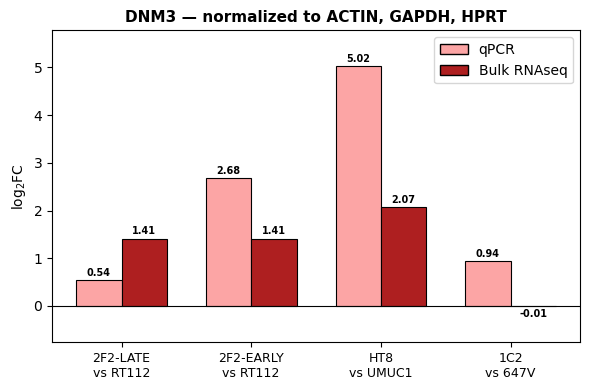

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/tim_upregulated/qpcr_vs_rnaseq_DNM3.png


In [12]:
#TIM GENES UPREGULATED

individual_plot_qpcr_vs_rnaseq(
    qpcr_df=pd.concat([umuc1_ht8_qpcr_df, rt112_2f2_qpcr_df, v647_qpcr_df]),
    rnaseq_dfs=[
    rt112_2f2_rnaseq_df,               # 2F2 vs RT112 
    rt112_2f2_rnaseq_df,
    umuc1_ht8_rnaseq_df,            # HT8 vs UMUC1
    v647_rnaseq_df                  # 1C2 vs 647V
],
    comparisons=[
        ("2F2-LATE", "RT112"),
        ("2F2-EARLY", "RT112"),
        ("HT8", "UMUC1"),
        ("1C2", "647V")
    ],
    hkg=["actin", "gapdh", "hprt"],
    color1='#FCA5A5',
    color2='#AE1F20',
    genes_to_include=["DNM3"],
    output_folder=OUTPUT / "tim_upregulated"
)

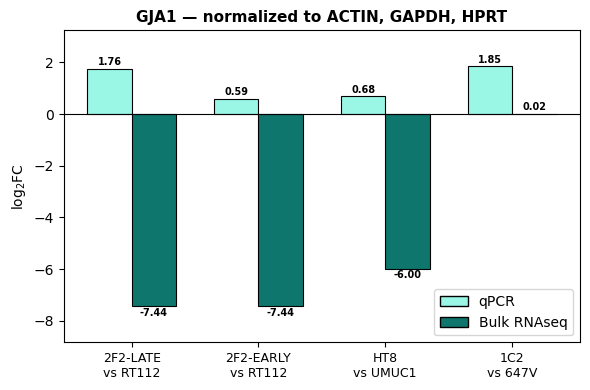

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/tim_downregulated/qpcr_vs_rnaseq_GJA1.png


In [13]:
#TIM GENES DOWNREGULATED

individual_plot_qpcr_vs_rnaseq(
    qpcr_df=pd.concat([umuc1_ht8_qpcr_df, rt112_2f2_qpcr_df, v647_qpcr_df]),
    rnaseq_dfs=[
    rt112_2f2_rnaseq_df,               # 2F2 vs RT112 
    rt112_2f2_rnaseq_df,
    umuc1_ht8_rnaseq_df,            # HT8 vs UMUC1
    v647_rnaseq_df                  # 1C2 vs 647V
],
    comparisons=[
        ("2F2-LATE", "RT112"),
        ("2F2-EARLY", "RT112"),
        ("HT8", "UMUC1"),
        ("1C2", "647V")
    ],
    hkg=["actin", "gapdh", "hprt"],
    color1='#9AF6E5',
    color2='#0F766E',
    genes_to_include=["GJA1"],
    output_folder=OUTPUT / "tim_downregulated"
)

Skipping GJB1 in HT8 vs UMUC1: No CT values found for UMUC1 / gjb1
Skipping DAPK1 in 2F2-LATE vs RT112: No CT values found for RT112 / dapk1
Skipping DAPK1 in 2F2-EARLY vs RT112: No CT values found for RT112 / dapk1
Skipping DAPK1 in 1C2 vs 647V: No CT values found for 647V / dapk1


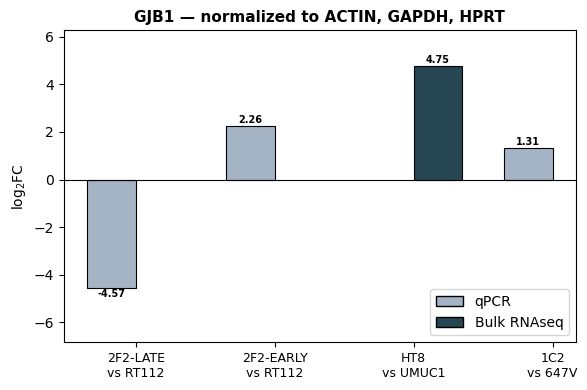

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/will_downregulated/qpcr_vs_rnaseq_GJB1.png


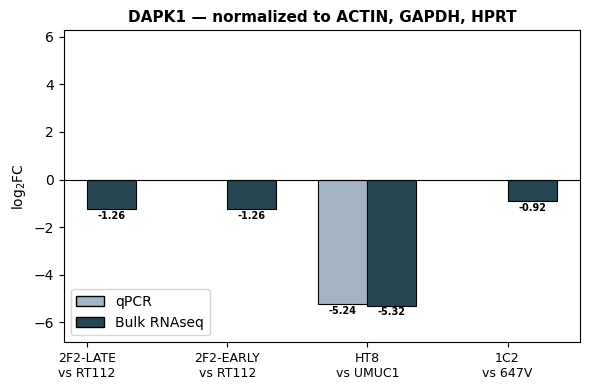

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/will_downregulated/qpcr_vs_rnaseq_DAPK1.png


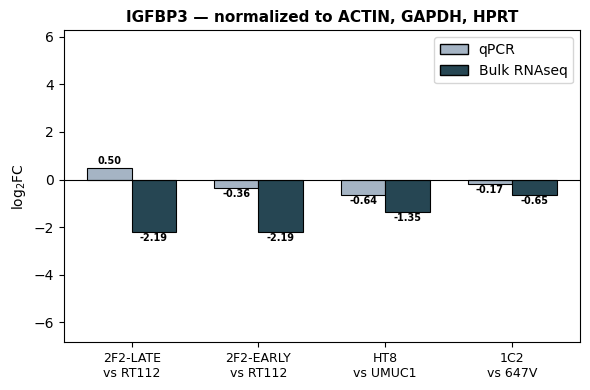

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/will_downregulated/qpcr_vs_rnaseq_IGFBP3.png


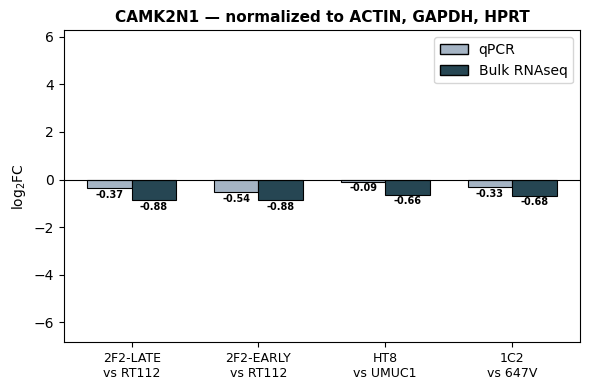

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/will_downregulated/qpcr_vs_rnaseq_CAMK2N1.png


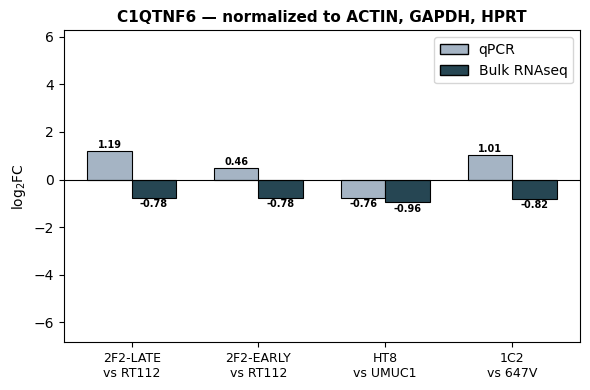

Saved as /Users/timothy/Documents/EV-Resistance-analysis/qPCR-validation/outs/will_downregulated/qpcr_vs_rnaseq_C1QTNF6.png


In [16]:
loaded_in_df = pd.read_csv("/Users/timothy/Downloads/qPCR Master Datasheet.xlsx - 6-30_ALL-samples_redo.csv")


tim_upregulated = [
    "AGAP2","DNM3","ADAM12","ABCB1","IL6","FZD8","TUBA4A","F2R","CTSE","CTSF","RET"
]

tim_downregulated = [
    "FAP","EHD3","GJA1","PSAPL1","PDZK1","ABCG1","BBC3","CHMP4B","CAV1","PPT2","NEDD4L",
]

will_upregulated = [
    "ZNF611","MELTF","IL32","UST","TMCC2","PLOD2","SAT1", "PSCK9", "PRSS1", "PRSS2", "ABCB1"
]


will_downregulated = [
    "GJB1", "KRT81","DAPK1","ZBED2","ACAT2","WNT10A","UPK1B","IGFBP3","S100A14","SLC7A5","EMP1","BCAT1","TPX2","CLIC4","SH2D4A", "CAMK2N1", "SH2D4A", "C1QTNF6", "SLC7A5"
]


individual_plot_qpcr_vs_rnaseq(
    qpcr_df=pd.concat([loaded_in_df, loaded_in_df, loaded_in_df]),
    rnaseq_dfs=[
    rt112_2f2_rnaseq_df,               # 2F2 vs RT112 
    rt112_2f2_rnaseq_df,
    umuc1_ht8_rnaseq_df,            # HT8 vs UMUC1
    v647_rnaseq_df                  # 1C2 vs 647V
],
    comparisons=[
        ("2F2-LATE", "RT112"),
        ("2F2-EARLY", "RT112"),
        ("HT8", "UMUC1"),
        ("1C2", "647V")
    ],
    hkg=["actin", "gapdh", "hprt"],
    color1='#A5B4C4',
    color2='#264653',
    genes_to_include=will_downregulated,
    output_folder=OUTPUT / "will_downregulated"
)